
Usando dispositivo: cpu

BENCHMARK

Sequence Length: 512
Standard Attention Time: 0.1424s
Flash Attention Time: 0.0640s
Mean Error: 0.00000002

Sequence Length: 1024
Standard Attention Time: 0.0177s
Flash Attention Time: 0.0110s
Mean Error: 0.00000002

Sequence Length: 2048
Standard Attention Time: 0.0650s
Flash Attention Time: 0.0407s
Mean Error: 0.00000001

Sequence Length: 4096
Standard Attention Time: 0.2756s
Flash Attention Time: 0.1900s
Mean Error: 0.00000001

RESULTADOS

Sequence: 512
Standard Time: 0.1424s
Flash Time: 0.0640s

Sequence: 1024
Standard Time: 0.0177s
Flash Time: 0.0110s

Sequence: 2048
Standard Time: 0.0650s
Flash Time: 0.0407s

Sequence: 4096
Standard Time: 0.2756s
Flash Time: 0.1900s


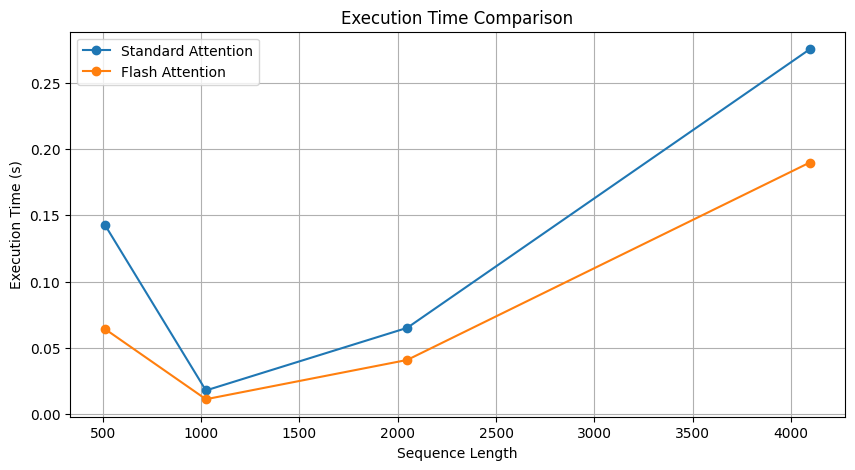


LONG CONTEXT TEST

Flash Attention with N=8192
Execution Time: 1.0788s
SUCCESS


In [2]:

# ============================================================
# Projeto: Flash Attention do Zero em PyTorch
# Arquivo único para portfólio
# ============================================================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time
import math

# ============================================================
# DEVICE
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"\nUsando dispositivo: {device}\n")

# ============================================================
# SELF-ATTENTION TRADICIONAL
# ============================================================

def standard_attention(Q, K, V):

    d_k = Q.size(-1)

    scores = torch.matmul(
        Q,
        K.transpose(-2, -1)
    )

    scores = scores / math.sqrt(d_k)

    attn = F.softmax(scores, dim=-1)

    output = torch.matmul(attn, V)

    return output


# ============================================================
# FLASH ATTENTION SIMPLIFICADA
# ============================================================

def flash_attention(Q, K, V, block_size=256):

    B, N, D = Q.shape

    output = torch.zeros_like(Q)

    scale = 1.0 / math.sqrt(D)

    # --------------------------------------------------------
    # Processa blocos de Q
    # --------------------------------------------------------

    for i in range(0, N, block_size):

        q_block = Q[:, i:i + block_size]

        row_max = None
        row_sum = None
        out_block = None

        # ----------------------------------------------------
        # Processa blocos de K/V
        # ----------------------------------------------------

        for j in range(0, N, block_size):

            k_block = K[:, j:j + block_size]
            v_block = V[:, j:j + block_size]

            # ------------------------------------------------
            # Attention local do bloco
            # ------------------------------------------------

            scores = torch.matmul(
                q_block,
                k_block.transpose(-2, -1)
            ) * scale

            current_max = scores.max(
                dim=-1,
                keepdim=True
            ).values

            # ------------------------------------------------
            # Primeiro bloco
            # ------------------------------------------------

            if row_max is None:

                row_max = current_max

                exp_scores = torch.exp(scores - row_max)

                row_sum = exp_scores.sum(
                    dim=-1,
                    keepdim=True
                )

                out_block = torch.matmul(
                    exp_scores,
                    v_block
                )

            # ------------------------------------------------
            # Softmax incremental estável
            # ------------------------------------------------

            else:

                new_max = torch.maximum(
                    row_max,
                    current_max
                )

                old_scale = torch.exp(row_max - new_max)

                exp_scores = torch.exp(scores - new_max)

                row_sum = (
                    old_scale * row_sum +
                    exp_scores.sum(
                        dim=-1,
                        keepdim=True
                    )
                )

                out_block = (
                    old_scale * out_block +
                    torch.matmul(
                        exp_scores,
                        v_block
                    )
                )

                row_max = new_max

        output[:, i:i + block_size] = out_block / row_sum

    return output


# ============================================================
# MEDIÇÃO DE MEMÓRIA
# ============================================================

def gpu_memory():

    if device == "cuda":

        allocated = (
            torch.cuda.memory_allocated()
            / 1024**2
        )

        reserved = (
            torch.cuda.memory_reserved()
            / 1024**2
        )

        return allocated, reserved

    return 0, 0


# ============================================================
# BENCHMARK
# ============================================================

sequence_lengths = [512, 1024, 2048, 4096]

standard_times = []
flash_times = []

standard_memory = []
flash_memory = []

B = 1
D = 64

print("=" * 60)
print("BENCHMARK")
print("=" * 60)

for N in sequence_lengths:

    print(f"\nSequence Length: {N}")

    Q = torch.randn(B, N, D, device=device)
    K = torch.randn(B, N, D, device=device)
    V = torch.randn(B, N, D, device=device)

    # ========================================================
    # STANDARD ATTENTION
    # ========================================================

    if device == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start = time.time()

    out_standard = standard_attention(Q, K, V)

    if device == "cuda":
        torch.cuda.synchronize()

    t_standard = time.time() - start

    mem_standard = (
        torch.cuda.max_memory_allocated() / 1024**2
        if device == "cuda"
        else 0
    )

    standard_times.append(t_standard)
    standard_memory.append(mem_standard)

    print(f"Standard Attention Time: {t_standard:.4f}s")

    # ========================================================
    # FLASH ATTENTION
    # ========================================================

    if device == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start = time.time()

    out_flash = flash_attention(
        Q,
        K,
        V,
        block_size=256
    )

    if device == "cuda":
        torch.cuda.synchronize()

    t_flash = time.time() - start

    mem_flash = (
        torch.cuda.max_memory_allocated() / 1024**2
        if device == "cuda"
        else 0
    )

    flash_times.append(t_flash)
    flash_memory.append(mem_flash)

    print(f"Flash Attention Time: {t_flash:.4f}s")

    # ========================================================
    # ERRO MÉDIO
    # ========================================================

    error = torch.mean(
        torch.abs(out_standard - out_flash)
    ).item()

    print(f"Mean Error: {error:.8f}")

# ============================================================
# RESULTADOS FINAIS
# ============================================================

print("\n" + "=" * 60)
print("RESULTADOS")
print("=" * 60)

for i, N in enumerate(sequence_lengths):

    print(f"\nSequence: {N}")

    print(
        f"Standard Time: "
        f"{standard_times[i]:.4f}s"
    )

    print(
        f"Flash Time: "
        f"{flash_times[i]:.4f}s"
    )

    if device == "cuda":

        print(
            f"Standard Memory: "
            f"{standard_memory[i]:.2f} MB"
        )

        print(
            f"Flash Memory: "
            f"{flash_memory[i]:.2f} MB"
        )

# ============================================================
# GRÁFICO DE TEMPO
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    sequence_lengths,
    standard_times,
    marker='o',
    label="Standard Attention"
)

plt.plot(
    sequence_lengths,
    flash_times,
    marker='o',
    label="Flash Attention"
)

plt.xlabel("Sequence Length")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time Comparison")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# GRÁFICO DE MEMÓRIA
# ============================================================

if device == "cuda":

    plt.figure(figsize=(10, 5))

    plt.plot(
        sequence_lengths,
        standard_memory,
        marker='o',
        label="Standard Attention"
    )

    plt.plot(
        sequence_lengths,
        flash_memory,
        marker='o',
        label="Flash Attention"
    )

    plt.xlabel("Sequence Length")
    plt.ylabel("Memory Usage (MB)")
    plt.title("GPU Memory Usage Comparison")

    plt.legend()

    plt.grid(True)

    plt.show()

# ============================================================
# TESTE COM CONTEXTO LONGO
# ============================================================

print("\n" + "=" * 60)
print("LONG CONTEXT TEST")
print("=" * 60)

try:

    N = 8192

    Q = torch.randn(B, N, D, device=device)
    K = torch.randn(B, N, D, device=device)
    V = torch.randn(B, N, D, device=device)

    start = time.time()

    out = flash_attention(
        Q,
        K,
        V,
        block_size=256
    )

    if device == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start

    print(f"\nFlash Attention with N={N}")
    print(f"Execution Time: {elapsed:.4f}s")
    print("SUCCESS")

except RuntimeError as e:

    print("\nOOM ERROR")
    print(e)

# ============================================================
# FIM
# ============================================================